Reatile Setilo


This project will:
*   Analyze transaction and customer data to identify trends and inconsistencies.
*   Develop metrics and examine sales drivers to gain insights into overall sales performance.
*   Create visualizations and prepare findings to formulate a clear recommendation for the client's strategy.

## 1. Load Libraries & Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='whitegrid')

In [5]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/'   # <-- update to your folder
transactionData = pd.read_excel(file_path + 'QVI_transaction_data.xlsx')
customerData    = pd.read_csv(file_path + 'QVI_purchase_behaviour.csv')


print('Transaction rows:', len(transactionData))
print('Customer rows   :', len(customerData))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Transaction rows: 264836
Customer rows   : 72637


## 2. Exploratory Data Analysis – Transaction Data

In [6]:
print(transactionData.dtypes)
transactionData.head()

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [7]:
# DATE is stored as an Excel integer – convert to proper date
# Excel serial dates start from 1899-12-30
transactionData['DATE'] = pd.to_datetime(
    transactionData['DATE'], unit='D', origin='1899-12-30'
)
print(transactionData['DATE'].dtype)
transactionData[['DATE']].head()

datetime64[ns]


,DATE
0,2018-10-17
1,2019-05-14
2,2019-05-20
3,2018-08-17
4,2018-08-18


In [8]:
# Examine words in PROD_NAME to check for non-chip products
all_words = ' '.join(transactionData['PROD_NAME'].unique()).split()
word_series = pd.Series(all_words)

# Remove tokens containing digits or only special characters
clean_words = word_series[
    ~word_series.str.contains(r'\d') &
     word_series.str.contains(r'[a-zA-Z]')
]

print(clean_words.value_counts().head(20))

Chips       21
Smiths      16
Cut         14
Crinkle     14
Kettle      13
Salt        12
Cheese      12
Original    10
Chip         9
Doritos      9
Salsa        9
Corn         8
Pringles     8
RRD          8
Chicken      7
WW           7
Sour         6
Sea          6
Vinegar      5
Thins        5
Name: count, dtype: int64


In [9]:
# Remove salsa products
transactionData = transactionData[
    ~transactionData['PROD_NAME'].str.lower().str.contains('salsa')
].copy()
print('Rows after salsa removal:', len(transactionData))

Rows after salsa removal: 246742


In [10]:
# Summary statistics – equivalent of summary()
transactionData.describe(include='all')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742,246742.000000,246742.000000
unique,NaN,NaN,NaN,NaN,NaN,105,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto 175g,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,NaN,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,NaN,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,NaN,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,NaN,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,NaN,200.000000,650.000000


In [11]:
# Investigate outlier: PROD_QTY == 200
print(transactionData[transactionData['PROD_QTY'] == 200])

# Check all transactions for that loyalty card
print(transactionData[transactionData['LYLTY_CARD_NBR'] == 226000])

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [12]:
# Remove the commercial buyer
transactionData = transactionData[
    transactionData['LYLTY_CARD_NBR'] != 226000
].copy()

print('Rows after outlier removal:', len(transactionData))
transactionData.describe()

Rows after outlier removal: 246740


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


In [13]:
# Count transactions per day and check for missing dates
txn_by_day = transactionData.groupby('DATE').size().reset_index(name='N')

all_dates = pd.DataFrame({
    'DATE': pd.date_range('2018-07-01', '2019-06-30')
})
txn_by_day = all_dates.merge(txn_by_day, on='DATE', how='left')

print('Total dates in range:', len(txn_by_day))
print('Missing dates:', txn_by_day['N'].isna().sum())

Total dates in range: 365
Missing dates: 1


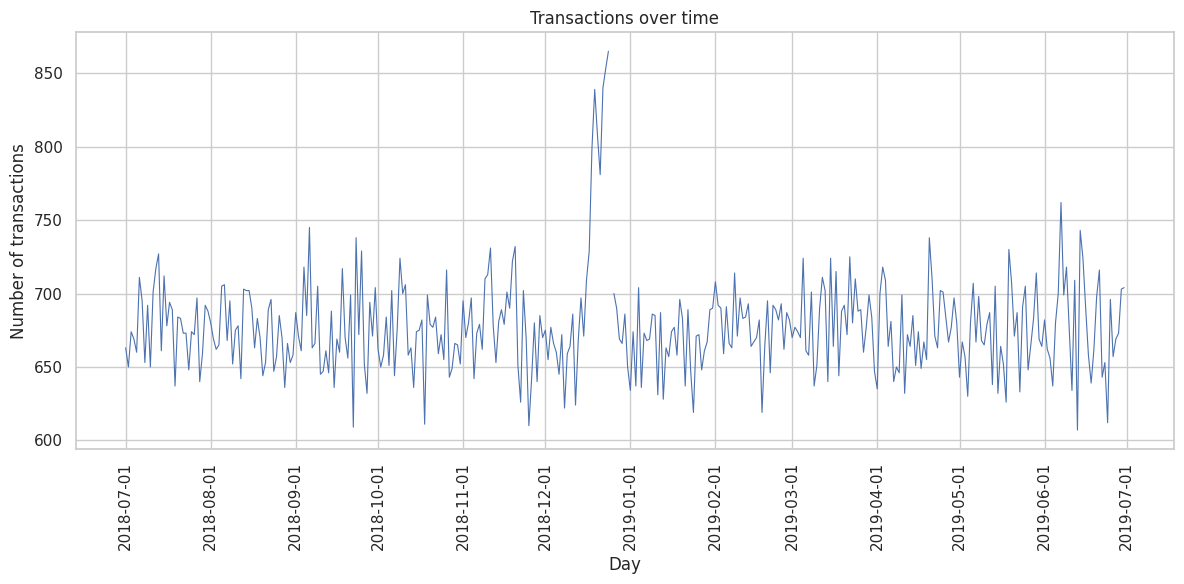

In [14]:
# Plot transactions over time
fig, ax = plt.subplots()
ax.plot(txn_by_day['DATE'], txn_by_day['N'], linewidth=0.8)
ax.set_title('Transactions over time')
ax.set_xlabel('Day')
ax.set_ylabel('Number of transactions')
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

there is an increase in purchases in December and a break in late December

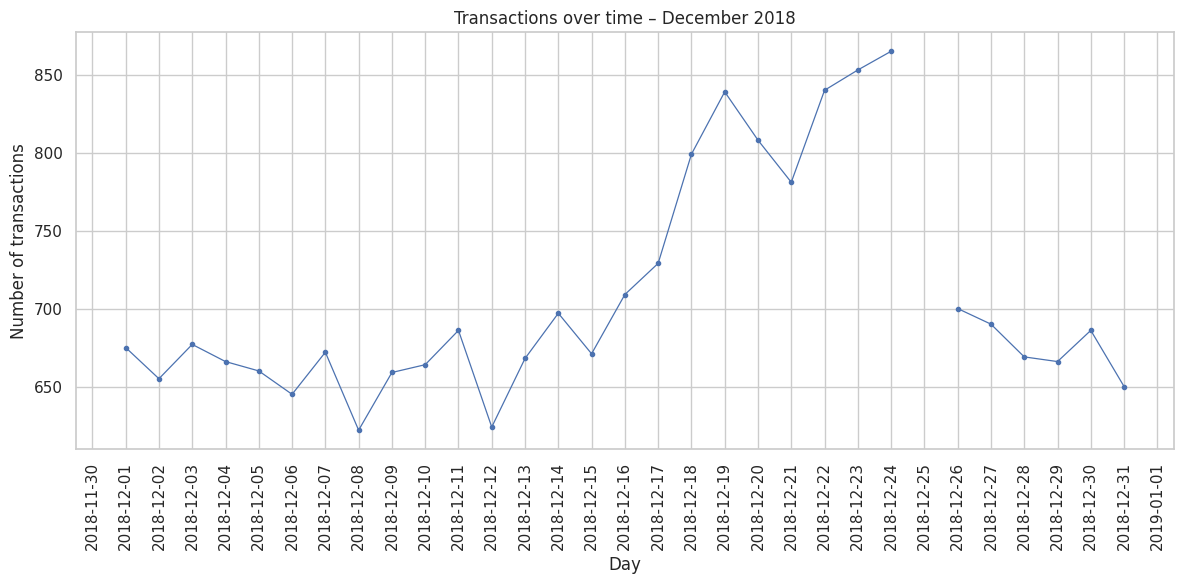

In [15]:
# Zoom into December
dec = txn_by_day[txn_by_day['DATE'].dt.month == 12]

fig, ax = plt.subplots()
ax.plot(dec['DATE'], dec['N'], marker='o', markersize=3, linewidth=0.9)
ax.set_title('Transactions over time – December 2018')
ax.set_xlabel('Day')
ax.set_ylabel('Number of transactions')
ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

the increase in sales occurs in the lead-up to Christmas and there are zero sales on Christmas day itself. This is due to shops being closed on Christmas day

The data contains no outliers so we move on to feauture engineering

## 3. Feature Engineering – Pack Size & Brand

In [16]:
# Extract pack size (first number found in product name)
transactionData['PACK_SIZE'] = (
    transactionData['PROD_NAME']
    .str.extract(r'(\d+)')
    .astype(int)
)

print(transactionData.groupby('PACK_SIZE').size().reset_index(name='N').to_string())

    PACK_SIZE      N
0          70   1507
1          90   3008
2         110  22387
3         125   1454
4         134  25102
5         135   3257
6         150  40203
7         160   2970
8         165  15297
9         170  19983
10        175  66390
11        180   1468
12        190   2995
13        200   4473
14        210   6272
15        220   1564
16        250   3169
17        270   6285
18        330  12540
19        380   6416


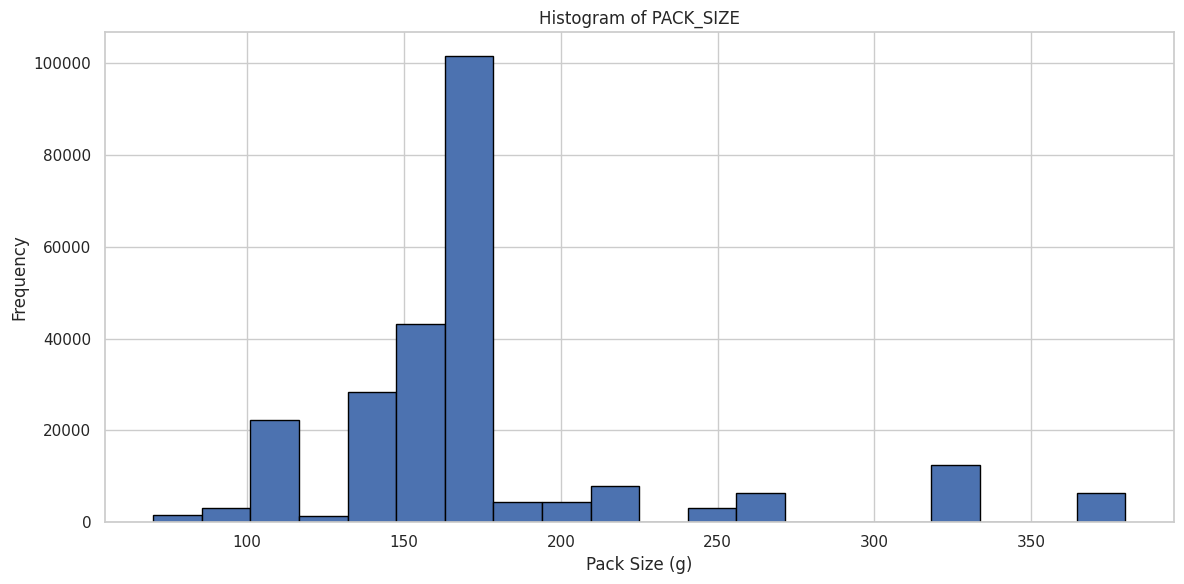

In [17]:
# Histogram of pack sizes
plt.hist(transactionData['PACK_SIZE'], bins=20, edgecolor='black')
plt.title('Histogram of PACK_SIZE')
plt.xlabel('Pack Size (g)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [18]:
# Extract brand = first word of PROD_NAME (uppercased)
transactionData['BRAND'] = (
    transactionData['PROD_NAME']
    .str.split().str[0]
    .str.upper()
)

print(transactionData.groupby('BRAND').size()
      .reset_index(name='N')
      .sort_values('N', ascending=False)
      .to_string())

         BRAND      N
12      KETTLE  41288
19      SMITHS  27390
15    PRINGLES  25102
6      DORITOS  22041
22       THINS  14075
17         RRD  11894
10   INFUZIONS  11057
27          WW  10320
4         COBS   9693
23    TOSTITOS   9471
24    TWISTIES   9454
25    TYRRELLS   6442
8        GRAIN   6272
13     NATURAL   6050
3     CHEEZELS   4603
1          CCS   4551
16         RED   4427
5       DORITO   3183
11      INFZNS   3144
18       SMITH   2963
2      CHEETOS   2927
20       SNBTS   1576
0       BURGER   1564
26  WOOLWORTHS   1516
9      GRNWVES   1468
21    SUNBITES   1432
14         NCC   1419
7       FRENCH   1418


In [19]:
# Standardise inconsistent brand names
brand_map = {
    'RED'    : 'RRD',
    'SNBTS'  : 'SUNBITES',
    'INFZNS' : 'INFUZIONS',
    'WW'     : 'WOOLWORTHS',
    'SMITH'  : 'SMITHS',
    'NCC'    : 'NATURAL',
    'DORITO' : 'DORITOS',
    'GRAIN'  : 'GRNWVES',
}
transactionData['BRAND'] = transactionData['BRAND'].replace(brand_map)

print(transactionData.groupby('BRAND').size()
      .reset_index(name='N')
      .sort_values('BRAND')
      .to_string())

         BRAND      N
0       BURGER   1564
1          CCS   4551
2      CHEETOS   2927
3     CHEEZELS   4603
4         COBS   9693
5      DORITOS  25224
6       FRENCH   1418
7      GRNWVES   7740
8    INFUZIONS  14201
9       KETTLE  41288
10     NATURAL   7469
11    PRINGLES  25102
12         RRD  16321
13      SMITHS  30353
14    SUNBITES   3008
15       THINS  14075
16    TOSTITOS   9471
17    TWISTIES   9454
18    TYRRELLS   6442
19  WOOLWORTHS  11836


## 4. Examine Customer Data

In [20]:
print(customerData.dtypes)
print(customerData.describe(include='all'))
customerData.head()

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object
        LYLTY_CARD_NBR LIFESTAGE PREMIUM_CUSTOMER
count     7.263700e+04     72637            72637
unique             NaN         7                3
top                NaN  RETIREES       Mainstream
freq               NaN     14805            29245
mean      1.361859e+05       NaN              NaN
std       8.989293e+04       NaN              NaN
min       1.000000e+03       NaN              NaN
25%       6.620200e+04       NaN              NaN
50%       1.340400e+05       NaN              NaN
75%       2.033750e+05       NaN              NaN
max       2.373711e+06       NaN              NaN


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [21]:
print(customerData.groupby('LIFESTAGE').size()
      .reset_index(name='N')
      .sort_values('N', ascending=False)
      .to_string())

print()
print(customerData.groupby('PREMIUM_CUSTOMER').size()
      .reset_index(name='N')
      .sort_values('N', ascending=False)
      .to_string())

                LIFESTAGE      N
4                RETIREES  14805
3   OLDER SINGLES/COUPLES  14609
6   YOUNG SINGLES/COUPLES  14441
2          OLDER FAMILIES   9780
5          YOUNG FAMILIES   9178
0  MIDAGE SINGLES/COUPLES   7275
1            NEW FAMILIES   2549

  PREMIUM_CUSTOMER      N
1       Mainstream  29245
0           Budget  24470
2          Premium  18922


## 5. Merge Datasets

In [22]:
# Left join – keep all transaction rows
data = transactionData.merge(customerData, on='LYLTY_CARD_NBR', how='left')

print('Merged rows:', len(data))
print('Null LIFESTAGE      :', data['LIFESTAGE'].isna().sum())
print('Null PREMIUM_CUSTOMER:', data['PREMIUM_CUSTOMER'].isna().sum())

Merged rows: 246740
Null LIFESTAGE      : 0
Null PREMIUM_CUSTOMER: 0


In [ ]:
# Optional: save merged data for Task 2
# data.to_csv(file_path + 'QVI_data.csv', index=False)

## 6. Customer Segment Analysis

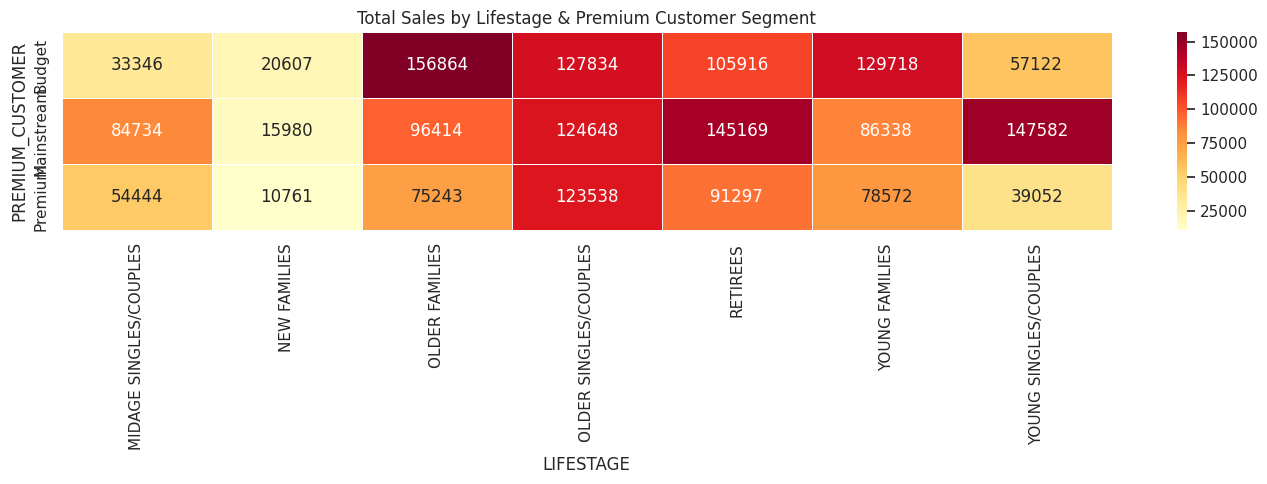

In [23]:
# Total sales by LIFESTAGE × PREMIUM_CUSTOMER
sales = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES']
    .sum()
    .reset_index(name='SALES')
)

sales_pivot = sales.pivot(index='PREMIUM_CUSTOMER', columns='LIFESTAGE', values='SALES')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(sales_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Total Sales by Lifestage & Premium Customer Segment')
plt.tight_layout()
plt.show()

Sales are coming mainly from Budget - older families, Mainstream - young singles/couples, and Mainstream - retirees

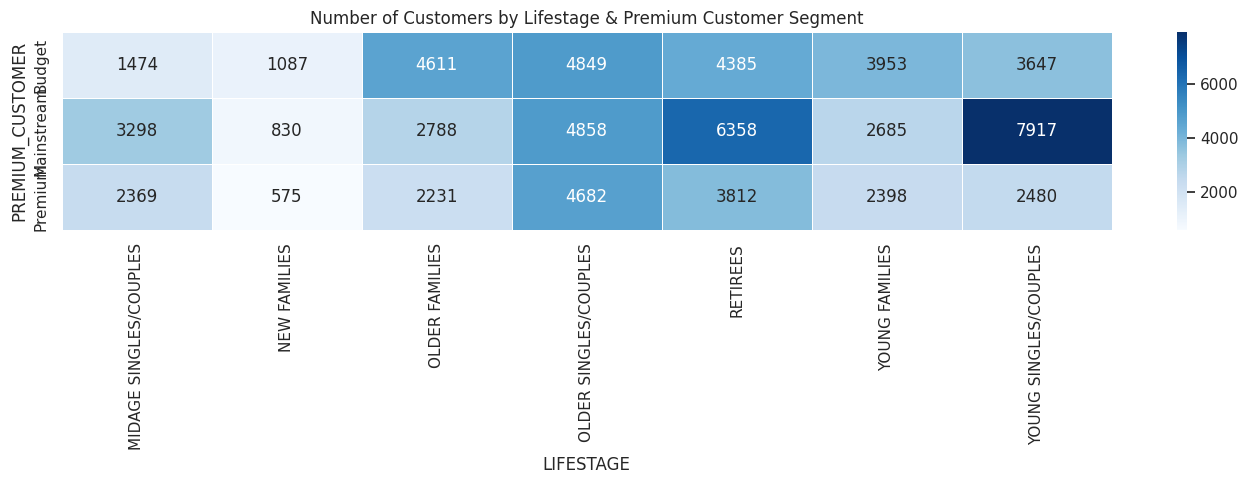

In [24]:
# Number of unique customers per segment
customers = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
    .nunique()
    .reset_index(name='CUSTOMERS')
    .sort_values('CUSTOMERS', ascending=False)
)

cust_pivot = customers.pivot(index='PREMIUM_CUSTOMER', columns='LIFESTAGE', values='CUSTOMERS')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cust_pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Number of Customers by Lifestage & Premium Customer Segment')
plt.tight_layout()
plt.show()

There are more Mainstream - young singles/couples and Mainstream - retirees who buy chips. This contributes to there being more sales to these customer segments but this is not a major driver for the Budget- Older families segment.

Higher sales may also be driven by more units of chips being bought per customer.

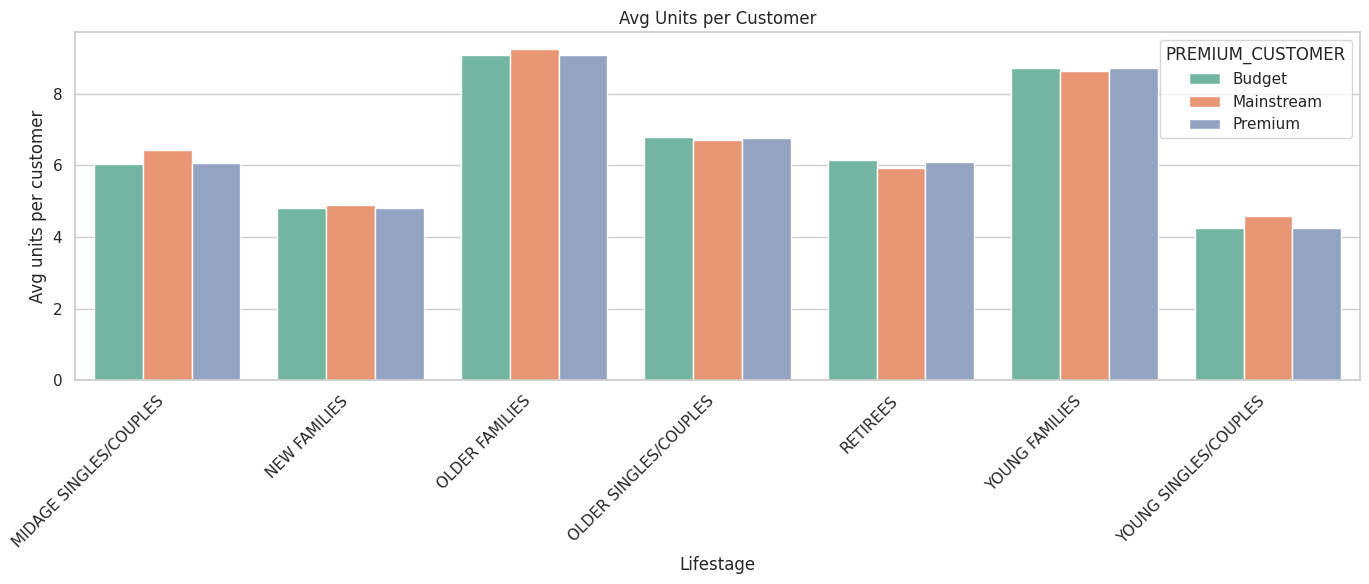

In [25]:
# Average units (chips packs) bought per customer, by segment
avg_units = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .apply(lambda g: g['PROD_QTY'].sum() / g['LYLTY_CARD_NBR'].nunique())
    .reset_index(name='AVG')
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=avg_units, x='LIFESTAGE', y='AVG',
    hue='PREMIUM_CUSTOMER', palette='Set2', ax=ax
)
ax.set_title('Avg Units per Customer')
ax.set_xlabel('Lifestage')
ax.set_ylabel('Avg units per customer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Older families and young families in general buy more chips per custome

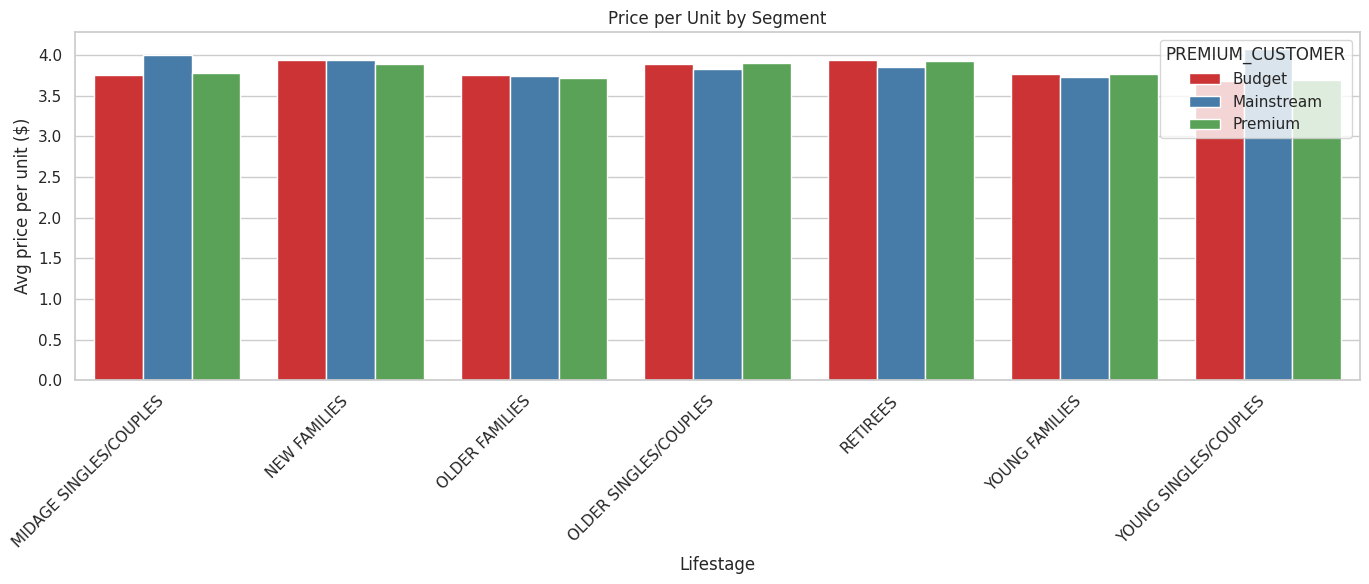

In [26]:
# Average price per unit by segment
avg_price = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .apply(lambda g: g['TOT_SALES'].sum() / g['PROD_QTY'].sum())
    .reset_index(name='AVG')
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=avg_price, x='LIFESTAGE', y='AVG',
    hue='PREMIUM_CUSTOMER', palette='Set1', ax=ax
)
ax.set_title('Price per Unit by Segment')
ax.set_xlabel('Lifestage')
ax.set_ylabel('Avg price per unit ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mainstream midage and young singles and couples are more willing to pay more per packet of chips compared to their budget and premium counterparts. This may be due to premium shoppers being more likely to
buy healthy snacks and when they buy chips, this is mainly for entertainment purposes rather than their own
consumption. This is also supported by there being fewer premium midage and young singles and couples
buying chips compared to their mainstream counterparts.

As the difference in average price per unit isn't large, we can check if this difference is statistically different

## 7. Statistical Test – Mainstream vs Budget/Premium (Young & Midage Singles/Couples)

In [27]:
# Price per unit column
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']

target_stages = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']

mainstream = data[
    data['LIFESTAGE'].isin(target_stages) &
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
]['PRICE_PER_UNIT']

others = data[
    data['LIFESTAGE'].isin(target_stages) &
    (data['PREMIUM_CUSTOMER'] != 'Mainstream')
]['PRICE_PER_UNIT']

t_stat, p_val = stats.ttest_ind(mainstream, others, alternative='greater')

print(f'Mainstream mean price : {mainstream.mean():.4f}')
print(f'Others mean price     : {others.mean():.4f}')
print(f'T-statistic           : {t_stat:.4f}')
print(f'P-value               : {p_val:.2e}')
print()
if p_val < 0.05:
    print('✅ Significant: Mainstream young/midage singles pay MORE per unit (p < 0.05)')
else:
    print('❌ Not significant')

Mainstream mean price : 4.0398
Others mean price     : 3.7065
T-statistic           : 37.8320
P-value               : 1.12e-309

✅ Significant: Mainstream young/midage singles pay MORE per unit (p < 0.05)


The t-test results in a p-value < 2.2e-16, i.e. the unit price for mainstream, young and mid-age singles and
couples are significantly higher than that of budget or premium, young and midage singles and couples.

## 8. Deep Dive – Mainstream Young Singles/Couples

In [28]:
segment1 = data[
    (data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
].copy()

other = data[
    ~((data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
      (data['PREMIUM_CUSTOMER'] == 'Mainstream'))
].copy()

print('Segment1 rows:', len(segment1))
print('Other rows   :', len(other))

Segment1 rows: 19544
Other rows   : 227196


In [29]:
# Brand affinity (index vs rest of population)
qty_seg1  = segment1['PROD_QTY'].sum()
qty_other = other['PROD_QTY'].sum()

seg1_brand  = segment1.groupby('BRAND')['PROD_QTY'].sum() / qty_seg1
other_brand = other.groupby('BRAND')['PROD_QTY'].sum() / qty_other

brand_aff = pd.DataFrame({
    'targetSegment': seg1_brand,
    'other'        : other_brand
}).dropna()
brand_aff['affinityToBrand'] = brand_aff['targetSegment'] / brand_aff['other']
brand_aff = brand_aff.sort_values('affinityToBrand', ascending=False)

print(brand_aff.to_string())

            targetSegment     other  affinityToBrand
BRAND                                               
TYRRELLS         0.031553  0.025692         1.228095
TWISTIES         0.046184  0.037877         1.219319
DORITOS          0.122761  0.101075         1.214553
KETTLE           0.197985  0.165553         1.195897
TOSTITOS         0.045411  0.037978         1.195713
PRINGLES         0.119420  0.100635         1.186670
COBS             0.044638  0.039049         1.143124
INFUZIONS        0.064679  0.057065         1.133435
THINS            0.060373  0.056986         1.059423
GRNWVES          0.032712  0.031188         1.048873
CHEEZELS         0.017971  0.018647         0.963753
SMITHS           0.096370  0.124584         0.773536
FRENCH           0.003948  0.005758         0.685569
CHEETOS          0.008033  0.012067         0.665733
RRD              0.043810  0.067494         0.649091
NATURAL          0.019600  0.030854         0.635241
CCS              0.011180  0.018896         0.

We can see that :
*   Mainstream young singles/couples are 23% more likely to purchase Tyrrells chips compared to the rest of the population
*   Mainstream young singles/couples are 56% less likely to purchase Burger Rings compared to the rest
of the population



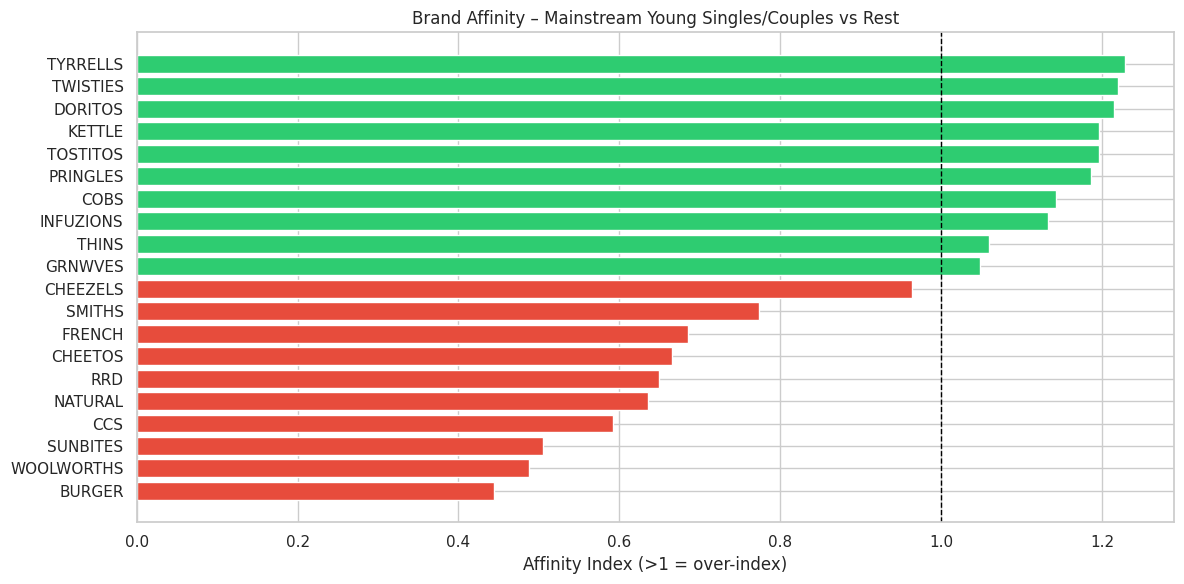

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if x >= 1 else '#e74c3c' for x in brand_aff['affinityToBrand']]
ax.barh(brand_aff.index, brand_aff['affinityToBrand'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_title('Brand Affinity – Mainstream Young Singles/Couples vs Rest')
ax.set_xlabel('Affinity Index (>1 = over-index)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
# Pack size affinity
seg1_pack  = segment1.groupby('PACK_SIZE')['PROD_QTY'].sum() / qty_seg1
other_pack = other.groupby('PACK_SIZE')['PROD_QTY'].sum() / qty_other

pack_aff = pd.DataFrame({
    'targetSegment': seg1_pack,
    'other'        : other_pack
}).dropna()
pack_aff['affinityToPack'] = pack_aff['targetSegment'] / pack_aff['other']
pack_aff = pack_aff.sort_values('affinityToPack', ascending=False)

print(pack_aff.to_string())

           targetSegment     other  affinityToPack
PACK_SIZE                                         
270             0.031829  0.025096        1.268287
380             0.032160  0.025584        1.257030
330             0.061284  0.050162        1.221717
134             0.119420  0.100635        1.186670
110             0.106280  0.089791        1.183637
210             0.029124  0.025121        1.159318
135             0.014769  0.013075        1.129511
250             0.014355  0.012781        1.123166
170             0.080773  0.080986        0.997370
150             0.157598  0.163421        0.964372
175             0.254990  0.270007        0.944382
165             0.055652  0.062268        0.893757
190             0.007481  0.012442        0.601271
180             0.003589  0.006067        0.591538
160             0.006404  0.012373        0.517616
90              0.006349  0.012580        0.504698
125             0.003009  0.006037        0.498442
200             0.008972  0.018

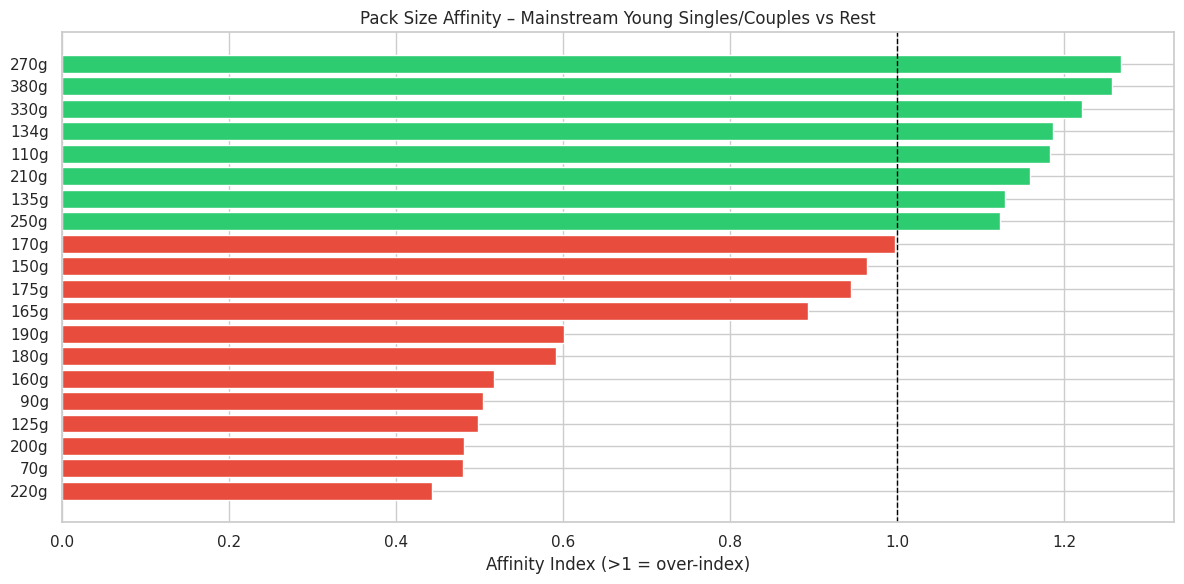

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if x >= 1 else '#e74c3c' for x in pack_aff['affinityToPack']]
ax.barh(pack_aff.index.astype(str) + 'g', pack_aff['affinityToPack'], color=colors)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_title('Pack Size Affinity – Mainstream Young Singles/Couples vs Rest')
ax.set_xlabel('Affinity Index (>1 = over-index)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

It looks like Mainstream young singles/couples are 27% more likely to purchase a 270g pack of chips compared to the rest of the population but let’s dive into what brands sell this pack size

In [33]:
# Which brands sell 270g packs?
print(data[data['PACK_SIZE'] == 270]['PROD_NAME'].unique())

['Twisties Cheese     270g' 'Twisties Chicken270g']


Twisties are the only brand offering 270g packs and so this may instead be reflecting a higher likelihood of
purchasing Twisties

## 9. Conclusion

- **Top revenue segments**: Budget – Older Families, Mainstream – Young Singles/Couples, Mainstream – Retirees.
- **Volume driver**: More Mainstream Young Singles/Couples and Retirees exist, explaining higher sales counts.
- **Price driver**: Mainstream midage & young singles/couples pay a statistically significantly higher price per unit (impulse buying behaviour).
- **Brand insight**: Mainstream Young Singles/Couples over-index on **Tyrrells, Twisties, and Kettle**.
- **Pack insight**: They prefer **larger packs (270g, 380g, 330g)**, driven mainly by Twisties.
- **Recommendation**: Off-locate Tyrrells and larger packs near areas frequented by young singles/couples to capitalise on impulse purchasing.